# Figure 2B & C

### Family - subgenus clustering of UHVDB

In [ ]:
%%bash
### Perform all-v-all alignment of UHVDB
# # split votu reps into smaller chunks
# seqkit split2 \
#     uhvdb.votu_reps.fna.gz \
#     --by-size 20000 \
#     --out-dir votu_reps_split

# # create diamond db
# sbatch diamond_makedb.sh

# # run all pairwise combinations of blastp
# sbatch diamond_blastp.sh

In [ ]:
### Calculate protein similarities
# # calculate self scores on self alignments
# sbatch diamond_selfscore.sh

# # calculate norm scores
# sbatch diamond_normscore.sh

In [ ]:
### Combine protein similarity scores and filter
import polars as pl
import glob

final_reps_set = set(pl.read_csv('vclust/uhvdb_vclust_votu_reps_final.tsv', has_header=False)['column_1'])

# combine all norm score files
df_list = []
for file in glob.glob('/gscratch/scrubbed/carsonjm/diamond_blastp/votu_reps.part_*.diamond_normscore.tsv'):
    df = (
        pl.read_csv(file, separator='\t', columns=['query', 'reference', 'norm_score'])
            .filter(
                (pl.col('norm_score') >= 5.5) &
                (pl.col('query').is_in(final_reps_set)) &
                (pl.col('reference').is_in(final_reps_set))
            )
    )
    df_list.append(df)

all_norm_scores = pl.concat(df_list)

all_norm_scores.write_csv('protein_similarity/uhvdb_family_normscores.tsv', separator='\t', include_header=False)

In [ ]:
%%bash
### Cluster UHVDB proteins into families with MCL
# mcl \
#     protein_similarity/uhvdb_family_normscores.tsv \
#     --abc \
#     -sort revsize \
#     -te 12 \
#     -o protein_similarity/uhvdb_family.normscores.mcl


In [ ]:
### Prune protein similarity graph to within subfamily connections and recluster
import polars as pl

# read mcl clusters to a dictionary
mcl = (
    pl.read_csv('protein_similarity/uhvdb_family.normscores.mcl', has_header=False, row_index_name='cluster_id', row_index_offset=1)
)

mcl_clusters = {}

for row in mcl.iter_rows(named=True):
    for member in row['column_1'].split('\t'):
        mcl_clusters[member] = row['cluster_id']


# load subfamily pruned graph
subfamily_pruned = (
    pl.read_csv('protein_similarity/uhvdb_family_normscores.tsv', separator='\t', has_header=False)
        .with_columns([
            pl.col('column_1').replace_strict(mcl_clusters, default='unassigned').alias('query_family'),
            pl.col('column_2').replace_strict(mcl_clusters, default='unassigned').alias('reference_family')
        ])
        .filter(
            (pl.col('query_family') == pl.col('reference_family')) &
            (pl.col('query_family') != 'unassigned') &
            (pl.col('column_3') >= 32)
        )
)


subfamily_pruned.write_csv('protein_similarity/uhvdb_subfamily_normscores.tsv', separator='\t', include_header=False)

!mcl \
    protein_similarity/uhvdb_subfamily_normscores.tsv \
    --abc \
    -sort revsize \
    -te 12 \
    -o protein_similarity/uhvdb_subfamily.normscores.mcl

In [ ]:
### Prune protein similarity graph to within genus connections and recluster
import polars as pl

# read mcl clusters to a dictionary
mcl = (
    pl.read_csv('protein_similarity/uhvdb_subfamily.normscores.mcl', has_header=False, row_index_name='cluster_id', row_index_offset=1)
)

mcl_clusters = {}

for row in mcl.iter_rows(named=True):
    for member in row['column_1'].split('\t'):
        mcl_clusters[member] = row['cluster_id']


# load genus pruned graph
genus_pruned = (
    pl.read_csv('protein_similarity/uhvdb_subfamily_normscores.tsv', separator='\t', has_header=False)
        .with_columns([
            pl.col('column_1').replace_strict(mcl_clusters, default='unassigned').alias('query_subfamily'),
            pl.col('column_2').replace_strict(mcl_clusters, default='unassigned').alias('reference_subfamily')
        ])
        .filter(
            (pl.col('query_subfamily') == pl.col('reference_subfamily')) &
            (pl.col('query_subfamily') != 'unassigned') &
            (pl.col('column_3') >= 65)
        )
)


genus_pruned.write_csv('protein_similarity/uhvdb_genus_normscores.tsv', separator='\t', include_header=False)

!mcl \
    protein_similarity/uhvdb_genus_normscores.tsv \
    --abc \
    -sort revsize \
    -te 12 \
    -o protein_similarity/uhvdb_genus.normscores.mcl

In [ ]:
### Cluster UHVDB proteins into subgenera with MCL
import polars as pl

# read mcl clusters to a dictionary
mcl = (
    pl.read_csv('protein_similarity/uhvdb_genus.normscores.mcl', has_header=False, row_index_name='cluster_id', row_index_offset=1)
)

mcl_clusters = {}

for row in mcl.iter_rows(named=True):
    for member in row['column_1'].split('\t'):
        mcl_clusters[member] = row['cluster_id']


# load subgenus pruned graph
subgenus_pruned = (
    pl.read_csv('protein_similarity/uhvdb_genus_normscores.tsv', separator='\t', has_header=False)
        .with_columns([
            pl.col('column_1').replace_strict(mcl_clusters, default='unassigned').alias('query_genus'),
            pl.col('column_2').replace_strict(mcl_clusters, default='unassigned').alias('reference_genus')
        ])
        .filter(
            (pl.col('query_genus') == pl.col('reference_genus')) &
            (pl.col('query_genus') != 'unassigned') &
            (pl.col('column_3') >= 80)
        )
)


subgenus_pruned.write_csv('protein_similarity/uhvdb_subgenus_normscores.tsv', separator='\t', include_header=False)

!mcl \
    protein_similarity/uhvdb_subgenus_normscores.tsv \
    --abc \
    -sort revsize \
    -te 12 \
    -o protein_similarity/uhvdb_subgenus.normscores.mcl

In [ ]:
### Count the number of UHVDB clusters at each taxonomic level
# new uhgv votu selection script
import polars as pl

def load_mcl_clusters(mcl, unique):
    # assign sequences to mcl clusters
    clusters = {}

    cluster_id = 0
    with open(mcl, 'r') as mcl_file:
        for line in mcl_file:
            cluster_id += 1
            for node in line.strip().split():
                clusters[node] = cluster_id
    print("Number of clusters from MCL:", cluster_id)

    # assign unclustered sequences to their own cluster
    with open(unique, 'r') as unique_file:
        for line in unique_file:
            sequence = line.strip().split()[0]
            if sequence not in clusters:
                cluster_id += 1
                clusters[sequence] = cluster_id

    print("Number of total clusters:", cluster_id)

    return clusters

In [ ]:
family_clusters = load_mcl_clusters('protein_similarity/uhvdb_family.normscores.mcl', 'vclust/uhvdb_vclust_votu_reps_final.tsv')
subfamily_clusters = load_mcl_clusters('protein_similarity/uhvdb_subfamily.normscores.mcl', 'vclust/uhvdb_vclust_votu_reps_final.tsv')
genus_clusters = load_mcl_clusters('protein_similarity/uhvdb_genus.normscores.mcl', 'vclust/uhvdb_vclust_votu_reps_final.tsv')
subgenus_clusters = load_mcl_clusters('protein_similarity/uhvdb_subgenus.normscores.mcl', 'vclust/uhvdb_vclust_votu_reps_final.tsv')

family_clusters_df = pl.DataFrame(list(family_clusters.items()), schema=["contig_id", "cluster_id"], orient='row')
family_clusters_df.write_csv('protein_similarity/uhvdb_family_clusters.tsv', separator='\t', include_header=True)

subfamily_clusters_df = pl.DataFrame(list(subfamily_clusters.items()), schema=["contig_id", "cluster_id"], orient='row')
subfamily_clusters_df.write_csv('protein_similarity/uhvdb_subfamily_clusters.tsv', separator='\t', include_header=True)

genus_clusters_df = pl.DataFrame(list(genus_clusters.items()), schema=["contig_id", "cluster_id"], orient='row')
genus_clusters_df.write_csv('protein_similarity/uhvdb_genus_clusters.tsv', separator='\t', include_header=True)

subgenus_clusters_df = pl.DataFrame(list(subgenus_clusters.items()), schema=["contig_id", "cluster_id"], orient='row')
subgenus_clusters_df.write_csv('protein_similarity/uhvdb_subgenus_clusters.tsv', separator='\t', include_header=True)

### UHVDB family-subgenus rarefaction + stability

In [ ]:
%%bash

# # clusters subsets 
# for rep in {1..5}; do
#     for subset in "1000" "5000" "10000" "20000" "50000" "100000" "150000" "200000"; do
#         mkdir -p aai_subset_${subset}/

#         shuf --random-source=<(yes $rep) -n $subset \
#             vclust/uhvdb_vclust_votu_reps_final.tsv \
#             > aai_subset_${subset}/uhvdb_vclust_votu_reps.subset${subset}_rep${rep}_ids.tsv

#         for rank in "subgenus" "genus" "subfamily" "family"; do
#             csvtk join --tabs \
#                 -f "1;1" \
#                 protein_similarity/uhvdb_${rank}_normscores.tsv \
#                 aai_subset_${subset}/uhvdb_vclust_votu_reps.subset${subset}_rep${rep}_ids.tsv | \
#             csvtk join --tabs \
#                 -f "2;1" \
#                 - aai_subset_${subset}/uhvdb_vclust_votu_reps.subset${subset}_rep${rep}_ids.tsv \
#                 --out-file aai_subset_${subset}/uhvdb_normscore.${rank}.subset${subset}_rep${rep}.tsv

#             micromamba run -n mcl \
#                 mcl \
#                     aai_subset_${subset}/uhvdb_normscore.${rank}.subset${subset}_rep${rep}.tsv \
#                     --abc \
#                     -sort revsize \
#                     -te 12 \
#                     -o uhvdb_vclust_votu_reps.${rank}.subset${subset}_rep${rep}.mcl
#         done
#     done
# done


Process is interrupted.


In [2]:
import polars as pl

def load_mcl_clusters(mcl, seq_id):
    # assign sequences to mcl clusters
    clusters = {}

    cluster_id = 0
    with open(mcl, 'r') as mcl_file:
        for line in mcl_file:
            cluster_id += 1
            for node in line.strip().split():
                clusters[node] = cluster_id

    # assign unclustered sequences to their own cluster
    with open(seq_id, 'r') as seqid_file:
        for line in seqid_file:
            sequence = line.strip().split()[0]
            if sequence not in clusters:
                cluster_id += 1
                clusters[sequence] = cluster_id

    # convert to a DataFrame
    clusters_df = pl.DataFrame({
        'seq_id': list(clusters.keys()),
        'cluster_id': list(clusters.values())
    })

    return clusters_df

In [ ]:
# calculate homogeneity and completeness scores for cluster subsets
from sklearn.metrics.cluster import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics import v_measure_score
import polars as pl

results = []

subsets = ['1000', '5000', '10000', '20000', '50000', '100000', '150000', '200000']

for rep in range(1, 6):
    for i in range(len(subsets)):
        for rank in ['subgenus', 'genus', 'subfamily', 'family']:
            clusters = load_mcl_clusters(f'uhvdb_vclust_votu_reps.{rank}.subset{subsets[i]}_rep{rep}.mcl', f'aai_subset_{subsets[i]}/uhvdb_vclust_votu_reps.subset{subsets[i]}_rep{rep}_ids.tsv').sort(pl.col('seq_id'), descending=False)
            multi_seq_clusters = set(clusters.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
            clusters_filt = clusters.filter(pl.col('cluster_id').is_in(multi_seq_clusters))

            clusters_full = load_mcl_clusters(f'protein_similarity/uhvdb_{rank}.normscores.mcl', 'vclust/uhvdb_vclust_votu_reps_final.tsv').sort(pl.col('seq_id'), descending=False)

            # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters
            h_score = homogeneity_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

            # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters
            c_score = completeness_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

            # calculate v-measure score
            v_score = v_measure_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

            results.append({
                "subset": subsets[i],
                "replicate": rep,
                "Rank": rank,
                "num_sequences": clusters['seq_id'].n_unique(),
                "Total clusters": clusters['cluster_id'].n_unique(),
                "num_seqs_in_multi_seq_clusters": clusters_filt['seq_id'].n_unique(),
                "Non-singleton clusters": clusters_filt['cluster_id'].n_unique(),
                "homogeneity": h_score,
                "completeness": c_score,
                "v-measure": v_score
            })

            # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters (merging lowers score)
            # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters (splitting lowers score)
            # v-measure: harmonic mean of homogeneity and completeness

            if subsets[i] == '1000' and rep == 1:
                multi_seq_clusters_full = set(clusters_full.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
                clusters_full_filt = clusters_full.filter(pl.col('cluster_id').is_in(multi_seq_clusters_full))

                results.append({
                    "subset": "201946",
                    "replicate": 1,
                    "Rank": rank,
                    "num_sequences": clusters_full['seq_id'].n_unique(),
                    "Total clusters": clusters_full['cluster_id'].n_unique(),
                    "num_seqs_in_multi_seq_clusters": clusters_full_filt['seq_id'].n_unique(),
                    "Non-singleton clusters": clusters_full_filt['cluster_id'].n_unique(),
                    "homogeneity": None,
                    "completeness": None,
                    "v-measure": None
                })

Text(0, 0.5, 'v-Measure score')

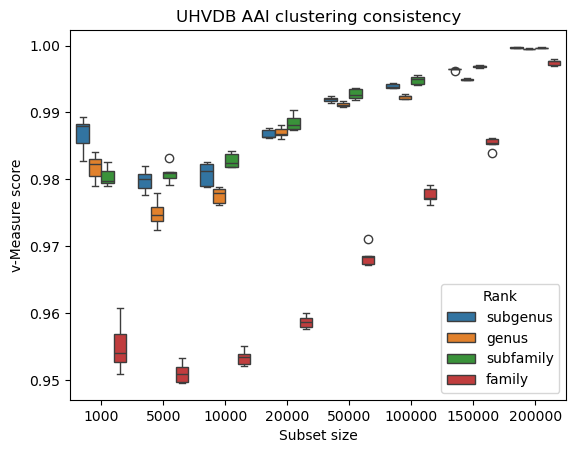

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

subset_results = (
    pl.from_dicts(results)
        .filter(pl.col("subset") != "201946")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
sns.boxplot(x="subset", y="v-measure", data=subset_results, hue="Rank")
plt.title("UHVDB AAI clustering consistency")
plt.xlabel("Subset size")
plt.ylabel("v-Measure score")

Text(0, 0.5, 'Number of subgenus')

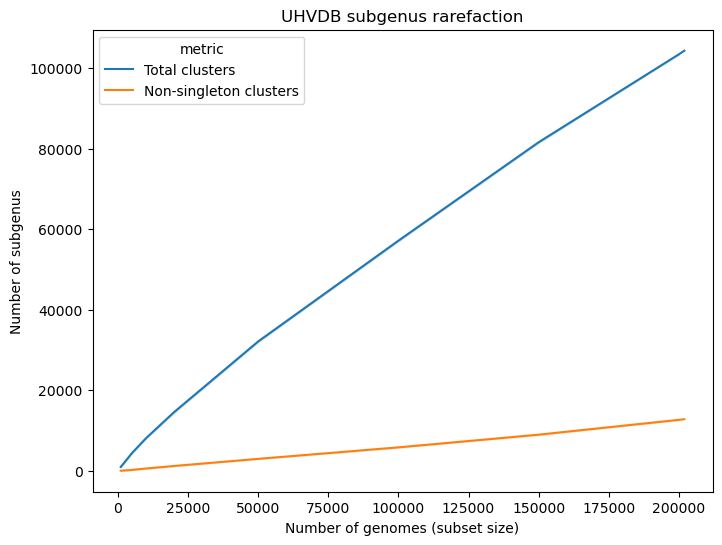

In [75]:
subset_cluster_counts = (
    pl.from_dicts(results)
        .with_columns([pl.col("subset").cast(pl.Int32)])
        .unpivot(index=["subset", "replicate", "Rank"], on=["Total clusters", "Non-singleton clusters"], variable_name="metric", value_name="value")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
plt.figure(figsize=(8, 6))
sns.lineplot(x="subset", y="value", hue='metric', data=subset_cluster_counts.filter(pl.col('Rank') == 'subgenus'))
plt.title("UHVDB subgenus rarefaction")
plt.xlabel("Number of genomes (subset size)")
plt.ylabel("Number of subgenus")
# plt.yscale('log')

Text(0, 0.5, 'Number of genus')

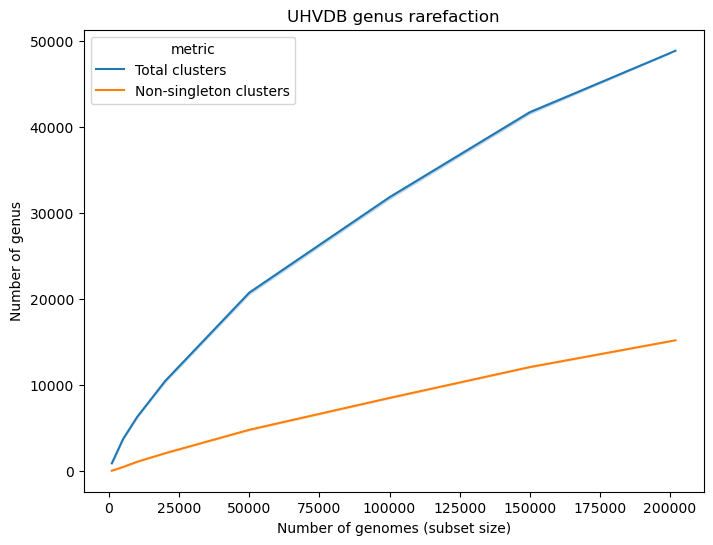

In [74]:
# create a boxplot of v-measure, homogeneity, and completeness scores by subset
plt.figure(figsize=(8, 6))
sns.lineplot(x="subset", y="value", hue='metric', data=subset_cluster_counts.filter(pl.col('Rank') == 'genus'))
plt.title("UHVDB genus rarefaction")
plt.xlabel("Number of genomes (subset size)")
plt.ylabel("Number of genus")
# plt.yscale('log')

Text(0, 0.5, 'Number of subfamily')

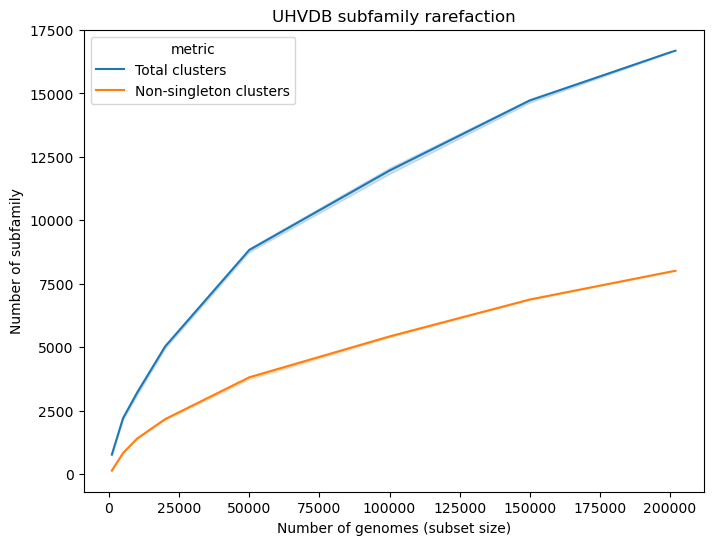

In [73]:
# create a boxplot of v-measure, homogeneity, and completeness scores by subset
plt.figure(figsize=(8, 6))
sns.lineplot(x="subset", y="value", hue='metric', data=subset_cluster_counts.filter(pl.col('Rank') == 'subfamily'))
plt.title("UHVDB subfamily rarefaction")
plt.xlabel("Number of genomes (subset size)")
plt.ylabel("Number of subfamily")
# plt.yscale('log')

Text(0, 0.5, 'Number of families')

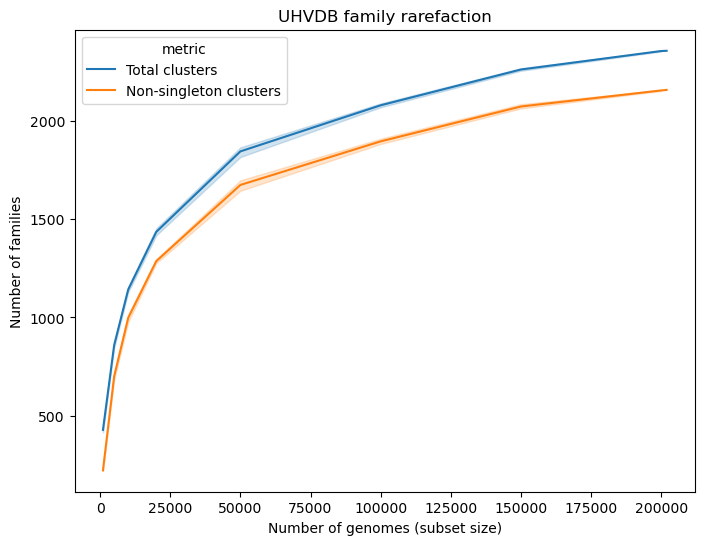

In [72]:
# create a boxplot of v-measure, homogeneity, and completeness scores by subset
plt.figure(figsize=(8, 6))
sns.lineplot(x="subset", y="value", hue='metric', data=subset_cluster_counts.filter(pl.col('Rank') == 'family'))
plt.title("UHVDB family rarefaction")
plt.xlabel("Number of genomes (subset size)")
plt.ylabel("Number of families")
# plt.yscale('log')

In [ ]:
# calculate homogeneity and completeness scores for cluster subsets
from sklearn.metrics.cluster import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics import v_measure_score
import polars as pl

results = []

subsets = ['1000', '5000', '10000', '20000', '50000', '100000', '150000', '200000']

for rep in range(1, 6):
    for i in range(len(subsets)):
        for cluster_size in [1, 5, 10, 20, 50, 100]:
            clusters = load_mcl_clusters(f'uhvdb_vclust_votu_reps.family.subset{subsets[i]}_rep{rep}.mcl', f'aai_subset_{subsets[i]}/uhvdb_vclust_votu_reps.subset{subsets[i]}_rep{rep}_ids.tsv').sort(pl.col('seq_id'), descending=False)
            multi_seq_clusters = set(clusters.group_by('cluster_id').len().filter(pl.col('len') > cluster_size)['cluster_id'])
            if len(multi_seq_clusters) < 10:
                continue
            clusters_filt = clusters.filter(pl.col('cluster_id').is_in(multi_seq_clusters))

            clusters_full = load_mcl_clusters('protein_similarity/uhvdb_family.normscores.mcl', 'vclust/uhvdb_vclust_votu_reps_final.tsv').sort(pl.col('seq_id'), descending=False)

            # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters
            h_score = homogeneity_score(clusters_filt['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters_filt['seq_id']))['cluster_id'])

            # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters
            c_score = completeness_score(clusters_filt['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters_filt['seq_id']))['cluster_id'])

            # calculate v-measure score
            v_score = v_measure_score(clusters_filt['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters_filt['seq_id']))['cluster_id'])

            results.append({
                "subset": subsets[i],
                "replicate": rep,
                "Cluster size": cluster_size,
                "num_sequences": clusters_filt['seq_id'].n_unique(),
                "Total clusters": clusters_filt['cluster_id'].n_unique(),
                "homogeneity": h_score,
                "completeness": c_score,
                "v-measure": v_score
            })

            # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters (merging lowers score)
            # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters (splitting lowers score)
            # v-measure: harmonic mean of homogeneity and completeness

In [14]:
results

[{'subset': '1000',
  'replicate': 1,
  'Cluster size': 1,
  'num_sequences': 819,
  'Total clusters': 223,
  'homogeneity': np.float64(0.9728913780853686),
  'completeness': np.float64(0.9370818240061962),
  'v-measure': np.float64(0.9546509093821652)},
 {'subset': '1000',
  'replicate': 1,
  'Cluster size': 5,
  'num_sequences': 234,
  'Total clusters': 29,
  'homogeneity': np.float64(0.972469824006996),
  'completeness': np.float64(0.8894099145838537),
  'v-measure': np.float64(0.9290871855773556)},
 {'subset': '5000',
  'replicate': 1,
  'Cluster size': 1,
  'num_sequences': 4835,
  'Total clusters': 668,
  'homogeneity': np.float64(0.944873511123154),
  'completeness': np.float64(0.9509172476442099),
  'v-measure': np.float64(0.947885745738469)},
 {'subset': '5000',
  'replicate': 1,
  'Cluster size': 5,
  'num_sequences': 3681,
  'Total clusters': 319,
  'homogeneity': np.float64(0.9556495587113305),
  'completeness': np.float64(0.9416481338132706),
  'v-measure': np.float64(0.94

Text(0, 0.5, 'v-Measure score')

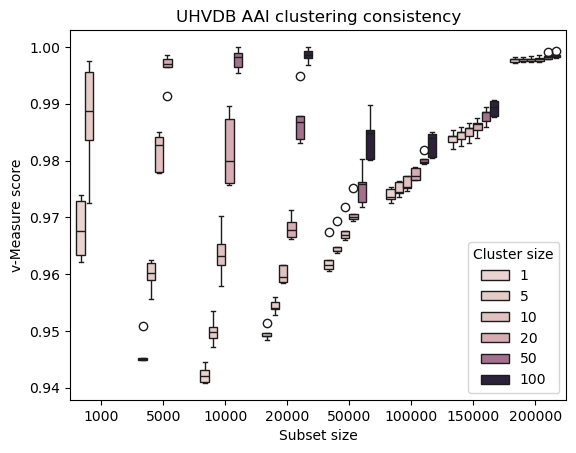

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

subset_results = (
    pl.from_dicts(results)
        .filter(pl.col("subset") != "201946")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
sns.boxplot(x="subset", y="homogeneity", data=subset_results, hue="Cluster size")
plt.title("UHVDB AAI clustering consistency")
plt.xlabel("Subset size")
plt.ylabel("v-Measure score")
# plt.ylim(0.9, 1.0)

Text(0, 0.5, 'v-Measure score')

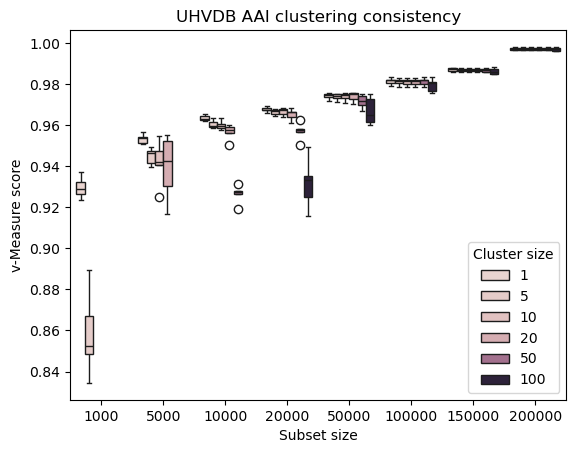

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

subset_results = (
    pl.from_dicts(results)
        .filter(pl.col("subset") != "201946")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
sns.boxplot(x="subset", y="completeness", data=subset_results, hue="Cluster size")
plt.title("UHVDB AAI clustering consistency")
plt.xlabel("Subset size")
plt.ylabel("v-Measure score")
# plt.ylim(0.9, 1.0)

Text(0, 0.5, 'v-Measure score')

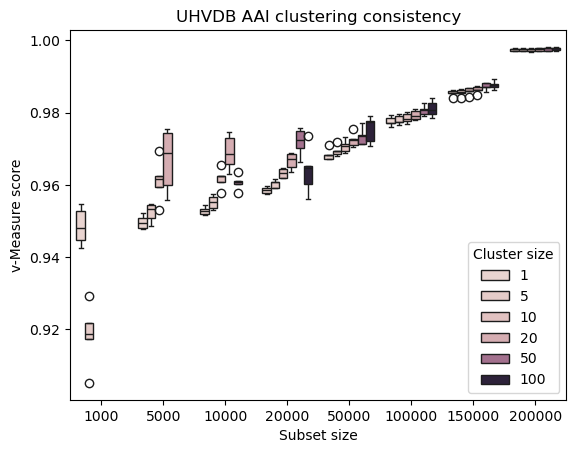

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

subset_results = (
    pl.from_dicts(results)
        .filter(pl.col("subset") != "201946")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
sns.boxplot(x="subset", y="v-measure", data=subset_results, hue="Cluster size")
plt.title("UHVDB AAI clustering consistency")
plt.xlabel("Subset size")
plt.ylabel("v-Measure score")
# plt.ylim(0.9, 1.0)